# OSM Point Features - Lyon

Downloads traffic signals, public transport stops and amenity POIs from OSM for Lyon,
counts them within a 50 m buffer of each street segment, normalizes by segment length
and exports `data/osm_points_features.csv`.
Roads loaded from `../layers/LYO_noise_streets.gpkg`.

In [1]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd

## Load roads

In [2]:
osm_roads = gpd.read_file("../layers/LYO_noise_streets.gpkg")
print(osm_roads.crs)
print(osm_roads.shape)
print(osm_roads.columns.tolist())
print("Number of street segments:", len(osm_roads))

EPSG:2154
(7159, 11)
['segment_id', 'highway', 'name', 'length', 'db_day', 'db_evening', 'db_night', 'noise_day', 'noise_evening', 'noise_night', 'geometry']
Number of street segments: 7159


## Traffic signals

In [3]:
signals = ox.features_from_place("Lyon, France", tags={"highway": "traffic_signals"})
signals = signals[signals.geometry.type == 'Point'].to_crs(osm_roads.crs)
print(signals.crs)
print(signals.columns.tolist())

EPSG:2154
['geometry', 'highway', 'direction', 'survey:date', 'traffic_signals', 'traffic_signals:direction', 'red_turn:right:bicycle', 'source', 'restriction:bicycle', 'railway', 'barrier', 'bicycle', 'foot', 'motorcar', 'motorcycle', 'crossing', 'red_turn:left:bicycle', 'red_turn:straight:bicycle', 'crossing:markings', 'traffic_signals:bus', 'button_operated', 'tactile_paving', 'traffic_signals:sound', 'traffic_signals:vibration', 'name', 'description', 'traffic_sign', 'traffic_sign:direction', 'mapillary', 'kerb', 'note', 'traffic_signals:countdown', 'check_date:crossing:barrier', 'crossing:barrier', 'red_turn:right', 'red_turn:straight', 'red_turn:2021-12-20', 'red_turn:2021-12-20:description:fr', 'description:fr', 'traffic_signals:bicycle', 'cycleway', 'support', 'red_turn:bicycle', 'red_turn:left']


In [4]:
print(f"Total signals: {len(signals)}")
if 'traffic_signals' in signals.columns:
    print(f"Non-null traffic_signals: {signals['traffic_signals'].notna().sum()}")
    print(f"Null traffic_signals: {signals['traffic_signals'].isna().sum()}")
    print("\nValue counts:")
    print(signals['traffic_signals'].value_counts(dropna=False))

Total signals: 2452
Non-null traffic_signals: 1647
Null traffic_signals: 805

Value counts:
traffic_signals
signal                 1299
NaN                     805
traffic_lights          306
bus_priority             24
tram_priority             7
pedestrian_crossing       6
blinker                   3
blink_mode                2
Name: count, dtype: int64


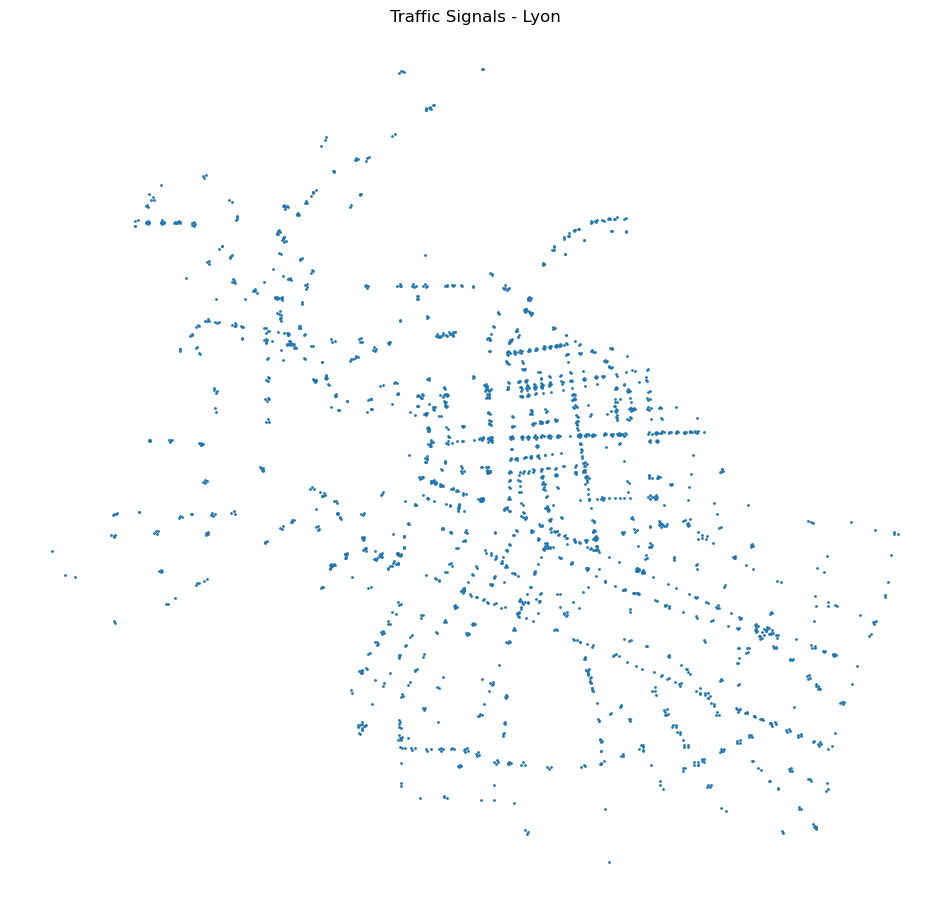

In [5]:
ax = signals.plot(markersize=1, figsize=(12, 12))
ax.set_title('Traffic Signals - Lyon')
ax.set_axis_off()

## Public transport stops

In [6]:
transport = ox.features_from_place(
    "Lyon, France",
    tags={"railway": ["station", "tram_stop", "subway_entrance"],
          "highway": "bus_stop"})
transport = transport[transport.geometry.type == 'Point'].to_crs(osm_roads.crs)
if 'railway' in transport.columns:
    transport['transport_type'] = transport['railway'].fillna(
        transport['highway'] if 'highway' in transport.columns else None
    )
elif 'highway' in transport.columns:
    transport['transport_type'] = transport['highway']
else:
    transport['transport_type'] = 'unknown'
print(transport.crs)
print(transport.columns.tolist())

EPSG:2154
['geometry', 'name', 'network', 'network:wikidata', 'operator', 'operator:wikidata', 'public_transport', 'railway', 'tram', 'wheelchair', 'bench', 'shelter', 'bus', 'highway', 'network:wikipedia', 'trolleybus', 'check_date:wheelchair', 'door', 'level', 'steps', 'survey:date', 'check_date', 'dog', 'tactile_paving', 'bin', 'check_date:shelter', 'lit', 'ref:FR:TCL', 'route_ref', 'source', 'amenity', 'departures_board', 'display', 'mapillary', 'pole', 'image', 'source:date', 'kerb', 'kerb:approach_aid', 'passenger_information_display', 'passenger_information_display:speech_output', 'ref', 'entrance', 'advertising', 'disused:highway', 'disused:public_transport', 'panoramax', 'old_name', 'clock', 'repeat_on', 'wikimedia_commons', 'layer', 'poster_box_shelter', 'conveying', 'toilets:wheelchair', 'check_date:lit', 'gtfs_id', 'alt_name', 'local_ref', 'note', 'covered', 'check_date:bench', 'check_date:bin', 'check_date:tactile_paving', 'wikidata', 'wikipedia', 'access', 'display:digita

In [7]:
print(f"Total transport points: {len(transport)}")
print(f"Non-null transport points: {transport['transport_type'].notna().sum()}")
print(f"Null transport points: {transport['transport_type'].isna().sum()}")
print("\nValue counts:")
print(transport['transport_type'].value_counts(dropna=False))

Total transport points: 1340
Non-null transport points: 1340
Null transport points: 0

Value counts:
transport_type
bus_stop           1031
subway_entrance     165
tram_stop           106
station              38
Name: count, dtype: int64


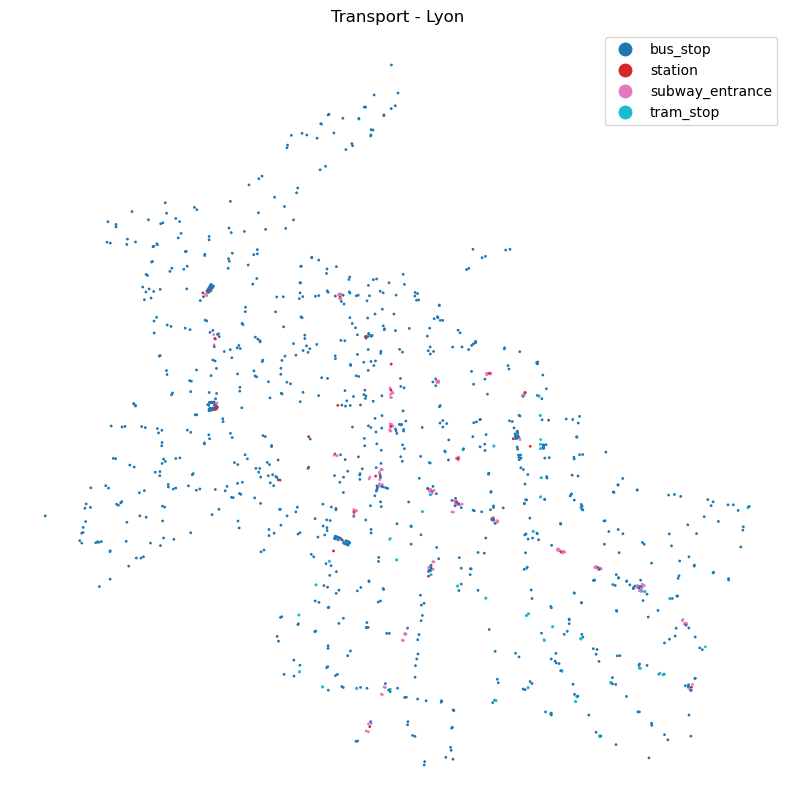

In [8]:
ax = transport.plot(column='transport_type', legend=True, markersize=1, figsize=(10, 10))
ax.set_title('Transport - Lyon')
ax.set_axis_off()

## POIs (amenities)

In [9]:
pois = ox.features_from_place(
    "Lyon, France",
    tags={"amenity": True}
)
pois = pois[pois.geometry.type == 'Point'].to_crs(osm_roads.crs)
print(pois.crs)
print(pois.columns.tolist())

EPSG:2154
['geometry', 'amenity', 'ferry', 'name', 'network', 'public_transport', 'source', 'brand', 'brand:wikidata', 'brand:wikipedia', 'compressed_air', 'fuel:diesel', 'fuel:e10', 'fuel:e85', 'fuel:lpg', 'fuel:octane_98', 'opening_hours', 'operator', 'ref:FR:prix-carburants', 'shop', 'toilets', 'vending', 'vending_machine', 'wheelchair', 'check_date', 'deaf:description:fr', 'operator:wikidata', 'operator:wikipedia', 'ref:FR:LaPoste', 'stamping_machine', 'website', 'contact:facebook', 'contact:instagram', 'cuisine', 'outdoor_seating', 'phone', 'ref:FR:SIRET', 'reservation', 'collection_times', 'ref', 'addr:city', 'addr:housenumber', 'addr:postcode', 'addr:street', 'brand:website', 'capacity', 'cinema:3D', 'ref:FR:CNC', 'screen', 'wikipedia', 'contact:housenumber', 'wikidata', 'email', 'check_date:opening_hours', 'opening_hours:signed', 'atm', 'change_machine', 'bicycle_rental', 'description', 'fee', 'network:website', 'network:wikidata', 'network:wikipedia', 'payment:app', 'rental', 

## Filter POI categories

In [10]:
filtered_categories = ['restaurant', 'cafe', 'bar', 'pub', 'nightclub', 'fast_food', 'food_court',
                        'music_venue', 'cinema', 'theatre', 'shopping_mall', 'shop', 'supermarket', 'marketplace']
pois_filtered = pois[pois['amenity'].isin(filtered_categories)]

traffic_categories = ['taxi']
pois_traffic = pois[pois['amenity'].isin(traffic_categories)]

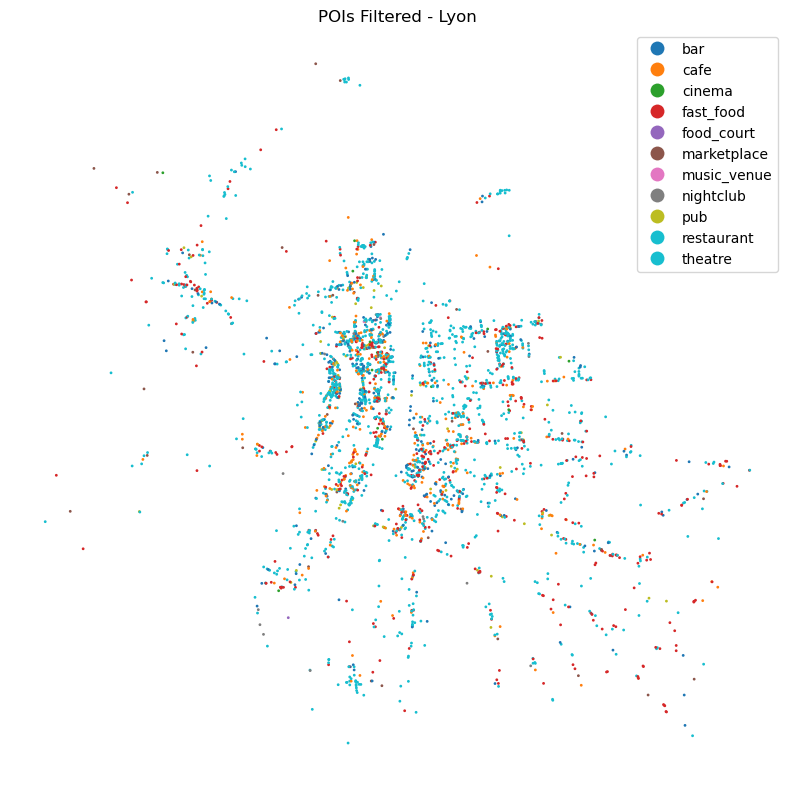

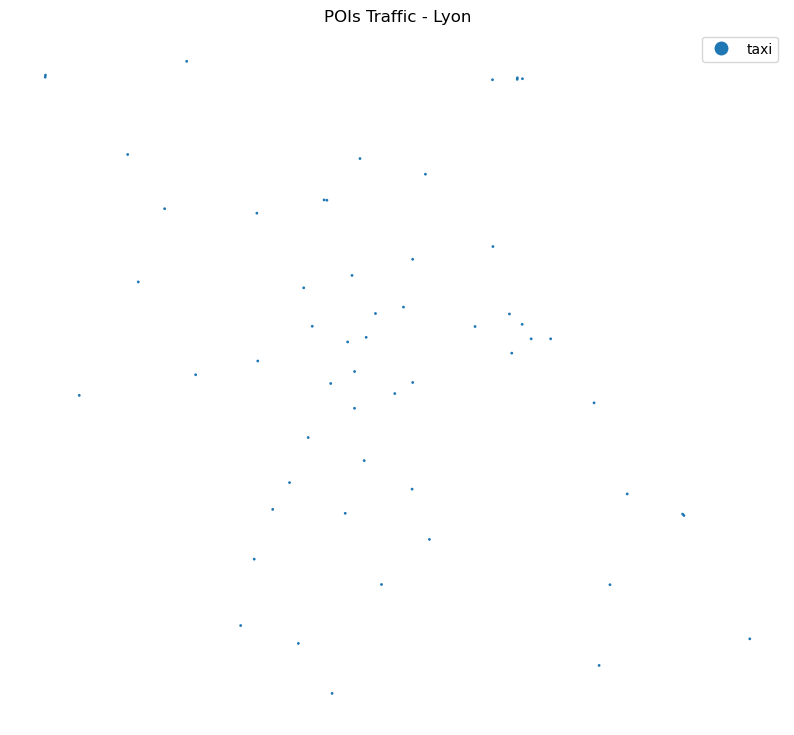

In [11]:
ax = pois_filtered.plot(figsize=(10, 10), column='amenity', legend=True, markersize=1)
ax.set_title('POIs Filtered - Lyon')
ax.set_axis_off()

ax = pois_traffic.plot(figsize=(10, 10), column='amenity', legend=True, markersize=1)
ax.set_title('POIs Traffic - Lyon')
ax.set_axis_off()

## Buffer streets by 50 m

In [12]:
buffered_50 = osm_roads.copy()
buffered_50['geometry'] = buffered_50.geometry.buffer(50)

## Count traffic signals per segment

In [13]:
signals_join = gpd.sjoin(signals, buffered_50, how="left", predicate="within")
signals_count = signals_join.groupby('index_right').size().rename('signal_count')

In [14]:
osm_roads_sig = osm_roads.join(signals_count)
osm_roads_sig['signal_count'] = osm_roads_sig['signal_count'].fillna(0) / osm_roads_sig['length']
q90 = osm_roads_sig['signal_count'].quantile(0.90)
osm_roads_sig['signal_count'] = osm_roads_sig['signal_count'].clip(upper=q90)
osm_roads_sig['signal_count'].describe()

count    7159.000000
mean        0.034758
std         0.047371
min         0.000000
25%         0.000000
50%         0.011707
75%         0.052592
max         0.142277
Name: signal_count, dtype: float64

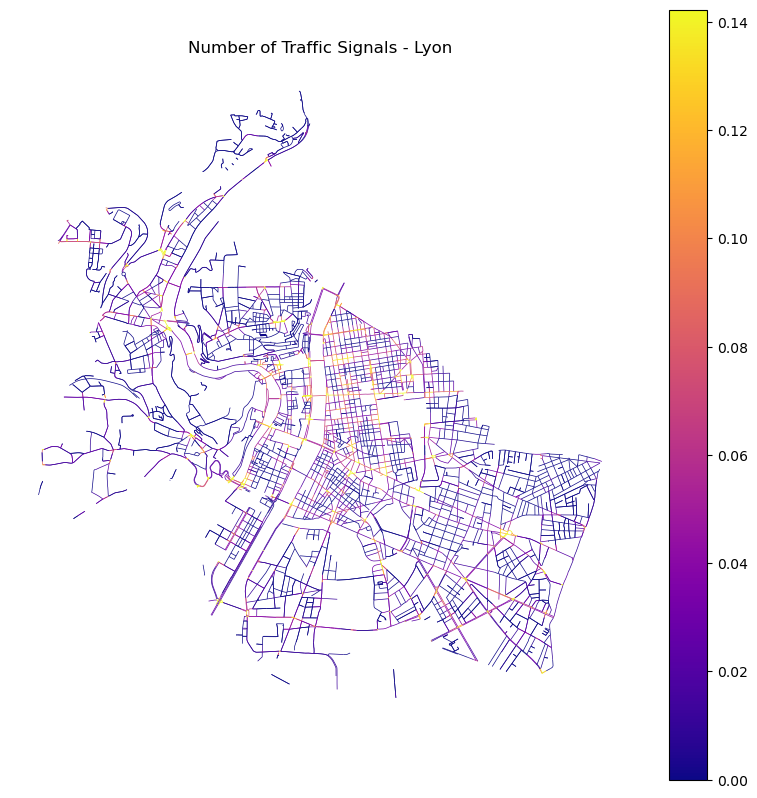

In [15]:
ax = osm_roads_sig.plot(column='signal_count', cmap='plasma', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Number of Traffic Signals - Lyon')
ax.set_axis_off()

## Count transport stops per segment

In [16]:
transport_join = gpd.sjoin(transport, buffered_50, how="left", predicate="within")
transport_count = transport_join.groupby('index_right').size().rename('transport_count')

traffic_join = gpd.sjoin(pois_traffic, buffered_50, how="left", predicate="within")
traffic_count = traffic_join.groupby('index_right').size().rename('traffic_count')

In [17]:
osm_roads_transport = osm_roads.join(transport_count)
osm_roads_transport = osm_roads_transport.join(traffic_count)
osm_roads_transport['transport_count'] = (
    osm_roads_transport['transport_count'].fillna(0) +
    osm_roads_transport['traffic_count'].fillna(0)
) / osm_roads_transport['length']
q90 = osm_roads_transport['transport_count'].quantile(0.90)
osm_roads_transport['transport_count'] = osm_roads_transport['transport_count'].clip(upper=q90)

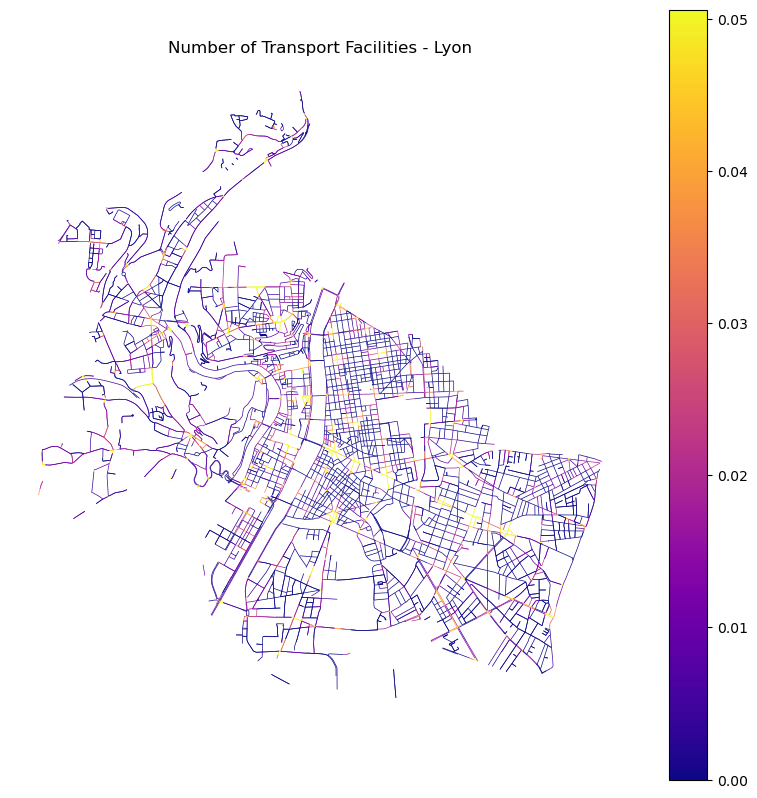

In [18]:
ax = osm_roads_transport.plot(column='transport_count', cmap='plasma', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Number of Transport Facilities - Lyon')
ax.set_axis_off()

## Count POIs per segment

In [19]:
pois_join = gpd.sjoin(pois_filtered, buffered_50, how="left", predicate="within")
pois_count = pois_join.groupby('index_right').size().rename('pois_count')
pois_count

index_right
3.0       1
5.0       1
6.0       1
7.0       3
8.0       3
         ..
7148.0    1
7150.0    9
7151.0    6
7152.0    5
7153.0    3
Name: pois_count, Length: 3702, dtype: int64

In [20]:
osm_roads_pois = osm_roads.join(pois_count)
osm_roads_pois['pois_count'] = osm_roads_pois['pois_count'].fillna(0) / osm_roads_pois['length']
q99 = osm_roads_pois['pois_count'].quantile(0.99)
osm_roads_pois['pois_count'] = osm_roads_pois['pois_count'].clip(upper=q99)

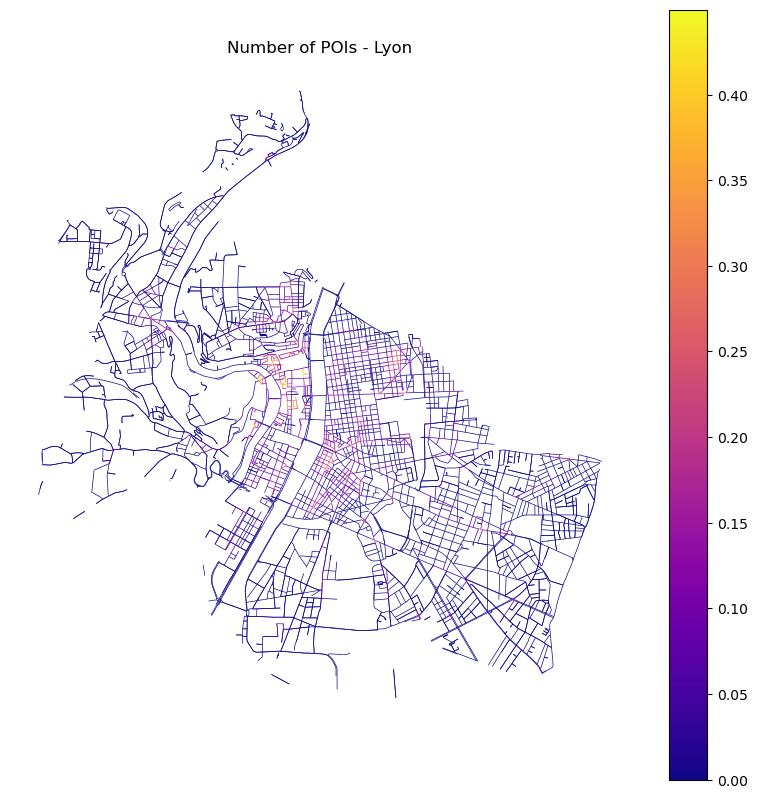

In [21]:
ax = osm_roads_pois.plot(column='pois_count', cmap='plasma', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Number of POIs - Lyon')
ax.set_axis_off()

## Merge and Export

In [22]:
dataset = pd.DataFrame({
    "road_id": osm_roads["segment_id"],
    "signals": osm_roads_sig["signal_count"],
    "transport": osm_roads_transport["transport_count"],
    "pois": osm_roads_pois["pois_count"],
}).fillna(0)
dataset.head()

,road_id,signals,transport,pois
0.0,143403_21714981_0,0.142277,0.000000,0.000000
1.0,143403_21718288_0,0.142277,0.000000,0.000000
2.0,143403_143408_0,0.078092,0.000000,0.000000
3.0,143408_21718264_0,0.012924,0.000000,0.003231
4.0,143408_932576340_0,0.085854,0.010732,0.000000


In [23]:
import os
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

path = os.path.join(output_dir, "osm_points_features.csv")
dataset.to_csv(path, index=False)
print(f"Exported: {path}")

Exported: data\osm_points_features.csv
